# Using: NYPD Stop, Question, Frisk Data (SQF)

## Among stopped individuals, after controlling for officers' stated reasons for suspicion, does race predict the probability of being frisked?

In [1]:
import statsmodels.formula.api as smf
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
import pandas as pd
from statsmodels.iolib.summary2 import summary_col


In [2]:
df = pd.read_excel('sqf-2025.xlsx')

In [3]:
df.head(10)

,STOP_ID,STOP_FRISK_DATE,STOP_FRISK_TIME,YEAR2,MONTH2,DAY2,STOP_WAS_INITIATED,ISSUING_OFFICER_RANK,ISSUING_OFFICER_COMMAND_CODE,SUPERVISING_OFFICER_RANK,...,SUSPECT_OTHER_DESCRIPTION,STOP_LOCATION_PRECINCT,STOP_LOCATION_SECTOR_CODE,STOP_LOCATION_APARTMENT,STOP_LOCATION_FULL_ADDRESS,STOP_LOCATION_STREET_NAME,STOP_LOCATION_X,STOP_LOCATION_Y,STOP_LOCATION_PATROL_BORO_NAME,STOP_LOCATION_BORO_NAME
0,298737273,2025-01-01,00:52:00,2025,January,Wednesday,Based on Self Initiated,PO,113,SGT,...,RED & BLACK CHECKERED SWEATSHIT GRAY SWEATPANT...,113,B,(null),MERRICK BLVD && FARMERS BLVD,MERRICK BLVD,1050370,187010,PBQS,QUEENS
1,298717444,2025-01-01,04:08:00,2025,January,Wednesday,Based on C/W on Scene,PO,19,SGT,...,UNKNOWN,019,B,(null),E 78 ST && 2 AVE,E 78 ST,996561,220779,PBMN,MANHATTAN
2,298737257,2025-01-01,01:08:00,2025,January,Wednesday,Based on Self Initiated,PO,183,SSA,...,GRAY SWEATSUIT,042,C,(null),COURTLANDT AVE && E 162 ST,COURTLANDT AVE,1007843,239931,PBBX,BRONX
3,298749315,2025-01-01,00:21:00,2025,January,Wednesday,Based on Self Initiated,PO,183,SSA,...,(null),042,A,(null),3 AVE && E 169 ST,3 AVE,1010531,242680,PBBX,BRONX
4,298749307,2025-01-01,17:53:00,2025,January,Wednesday,Based on Self Initiated,PO,28,SGT,...,(null),026,C,(null),W 127 ST && ST NICHOLAS AVE,W 127 ST,997674,235117,PBMN,MANHATTAN
5,298737268,2025-01-01,13:00:00,2025,January,Wednesday,Based on Radio Run,PO,90,SGT,...,(null),090,C,(null),LORIMER ST && SCHOLES ST,LORIMER ST,998550,197336,PBBN,BROOKLYN
6,298737265,2025-01-01,03:36:00,2025,January,Wednesday,Based on Self Initiated,PO,81,LT,...,(null),081,C,(null),218 MALCOLM X BLVD,MALCOLM X BLVD,1003727,189137,PBBN,BROOKLYN
7,298749345,2025-01-01,14:20:00,2025,January,Wednesday,Based on Radio Run,PO,121,SGT,...,(null),121,C,(null),2353 RICHMOND AVE,RICHMOND AVE,938479,154535,PBSI,STATEN ISLAND
8,298765810,2025-01-01,23:32:00,2025,January,Wednesday,Based on Radio Run,PO,115,SGT,...,BLACK HAT YELLOW PUFFER COAT BLACK PANTS WHITE...,115,D,(null),37-76 JUNCTION BLVD,JUNCTION BLVD,1020313,212396,PBQN,QUEENS
9,298737270,2025-01-01,10:30:00,2025,January,Wednesday,Based on Radio Run,PO,103,LT,...,(null),103,A,4L,88-25 153 ST,153 ST,1038722,196359,PBQS,QUEENS


### Part 1: Frisk Rates

In [4]:
df['FRISKED_NUM'] = df['FRISKED_FLAG'].map({'Y': 1, 'N': 0})
df.drop(columns='FRISKED_FLAG')
df['PHYSICAL_FORCE_VERBAL_INSTRUCTION_NUM'] = df['PHYSICAL_FORCE_VERBAL_INSTRUCTION_FLAG'].map({'Y': 1, 'N': 0})
df.drop(columns='PHYSICAL_FORCE_VERBAL_INSTRUCTION_FLAG')

,STOP_ID,STOP_FRISK_DATE,STOP_FRISK_TIME,YEAR2,MONTH2,DAY2,STOP_WAS_INITIATED,ISSUING_OFFICER_RANK,ISSUING_OFFICER_COMMAND_CODE,SUPERVISING_OFFICER_RANK,...,STOP_LOCATION_SECTOR_CODE,STOP_LOCATION_APARTMENT,STOP_LOCATION_FULL_ADDRESS,STOP_LOCATION_STREET_NAME,STOP_LOCATION_X,STOP_LOCATION_Y,STOP_LOCATION_PATROL_BORO_NAME,STOP_LOCATION_BORO_NAME,FRISKED_NUM,PHYSICAL_FORCE_VERBAL_INSTRUCTION_NUM
0,298737273,2025-01-01,00:52:00,2025,January,Wednesday,Based on Self Initiated,PO,113,SGT,...,B,(null),MERRICK BLVD && FARMERS BLVD,MERRICK BLVD,1050370,187010,PBQS,QUEENS,0,1.0
1,298717444,2025-01-01,04:08:00,2025,January,Wednesday,Based on C/W on Scene,PO,19,SGT,...,B,(null),E 78 ST && 2 AVE,E 78 ST,996561,220779,PBMN,MANHATTAN,0,1.0
2,298737257,2025-01-01,01:08:00,2025,January,Wednesday,Based on Self Initiated,PO,183,SSA,...,C,(null),COURTLANDT AVE && E 162 ST,COURTLANDT AVE,1007843,239931,PBBX,BRONX,1,1.0
3,298749315,2025-01-01,00:21:00,2025,January,Wednesday,Based on Self Initiated,PO,183,SSA,...,A,(null),3 AVE && E 169 ST,3 AVE,1010531,242680,PBBX,BRONX,1,1.0
4,298749307,2025-01-01,17:53:00,2025,January,Wednesday,Based on Self Initiated,PO,28,SGT,...,C,(null),W 127 ST && ST NICHOLAS AVE,W 127 ST,997674,235117,PBMN,MANHATTAN,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26417,318286652,2025-12-31,19:33:00,2025,December,Wednesday,Based on C/W on Scene,DT3,318,SGT,...,C,(null),200 LIBERTY ST,LIBERTY ST,979983,198395,PBMS,MANHATTAN,1,1.0
26418,318243643,2025-12-31,23:43:00,2025,December,Wednesday,Based on Self Initiated,PO,105,SGT,...,B,(null),210 ST && MURDOCK AVE,210 ST,1054947,195326,PBQS,QUEENS,1,1.0
26419,318233826,2025-12-31,23:59:00,2025,December,Wednesday,Based on Self Initiated,PO,182,SGT,...,C,(null),MADISON AVE && E 108 ST,MADISON AVE,998494,228888,PBMN,MANHATTAN,0,1.0
26420,318276465,2025-12-31,14:46:00,2025,December,Wednesday,Based on Radio Run,SGT,13,LT,...,B,(null),16 E 16 ST,E 16 ST,986519,207736,PBMS,MANHATTAN,0,1.0


In [5]:
frisk_race = df.groupby('SUSPECT_RACE_DESCRIPTION').agg(
    frisk_rate=('FRISKED_NUM', 'mean'),
    n_stops=('FRISKED_NUM', 'count')
).sort_values('n_stops', ascending=False)
frisk_race

,frisk_rate,n_stops
SUSPECT_RACE_DESCRIPTION,,
BLACK,0.569121,15538
WHITE HISPANIC,0.471934,5594
BLACK HISPANIC,0.558531,2614
WHITE,0.279551,1692
ASIAN / PACIFIC ISLANDER,0.335593,590
MIDDLE EASTERN/SOUTHWEST ASIAN,0.405751,313
AMERICAN INDIAN/ALASKAN NATIVE,0.530864,81


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

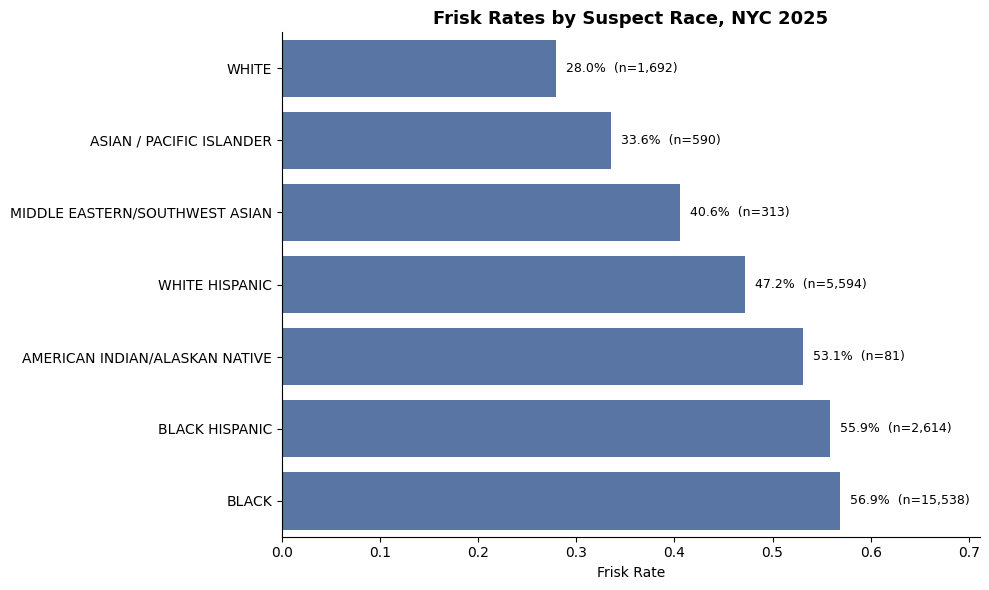

In [7]:
frisk_race_sorted = frisk_race.sort_values('frisk_rate', ascending=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=frisk_race_sorted,
    y='SUSPECT_RACE_DESCRIPTION',
    x='frisk_rate',
    color='#4C72B0' 
)

for i, (rate, n) in enumerate(zip(frisk_race_sorted['frisk_rate'],
                                   frisk_race_sorted['n_stops'])):
    ax.text(rate + 0.01, i, f'{rate:.1%}  (n={n:,})',
            va='center', fontsize=9)

plt.title('Frisk Rates by Suspect Race, NYC 2025', fontsize=13, fontweight='bold')
plt.xlabel('Frisk Rate')
plt.ylabel('')
plt.xlim(0, max(frisk_race_sorted['frisk_rate']) * 1.25)  # room for labels
sns.despine()
plt.tight_layout()
plt.savefig('frisk_rates_race_2025')
plt.show()

In [8]:
df['SUSPECT_SEX'].unique()

<StringArray>
['MALE', 'FEMALE', '(null)']
Length: 3, dtype: str

In [9]:
frisk_race_sex = df.groupby(['SUSPECT_RACE_DESCRIPTION', 'SUSPECT_SEX']).agg(
    frisk_rate=('FRISKED_NUM', 'mean'),
    n_stops=('FRISKED_NUM', 'count')
)
# print(frisk_race_sex)
frisk_race_sex

frisk_rate  n_stops
SUSPECT_RACE_DESCRIPTION       SUSPECT_SEX                     
AMERICAN INDIAN/ALASKAN NATIVE (null)         1.000000        1
                               FEMALE         0.500000        2
                               MALE           0.525641       78
ASIAN / PACIFIC ISLANDER       (null)         1.000000        9
                               FEMALE         0.113208       53
                               MALE           0.346591      528
BLACK                          (null)         0.730337       89
                               FEMALE         0.213425     1162
                               MALE           0.597046    14287
BLACK HISPANIC                 (null)         0.807692       26
                               FEMALE         0.226027      146
                               MALE           0.575758     2442
MIDDLE EASTERN/SOUTHWEST ASIAN (null)         1.000000        7
                               FEMALE         0.125000        8
                               MALE           0.399329      298
WHITE                          (null)         0.750000       12
                               FEMALE         0.106762      281
                               MALE           0.310222     1399
WHITE HISPANIC                 (null)         0.703704       27
                               FEMALE         0.192560      457
                               MALE           0.495695     5110

In [10]:
frisk_race_boro = df.groupby(['STOP_LOCATION_BORO_NAME', 'SUSPECT_RACE_DESCRIPTION']).agg(
    frisk_rate=('FRISKED_NUM', 'mean'),
    n_counts=('FRISKED_NUM', 'count')
).sort_values('n_counts', ascending=False)
print(frisk_race_boro)

                                                        frisk_rate  n_counts
STOP_LOCATION_BORO_NAME SUSPECT_RACE_DESCRIPTION                            
BROOKLYN                BLACK                             0.575741      5631
BRONX                   BLACK                             0.742894      4679
MANHATTAN               BLACK                             0.421146      2809
BRONX                   WHITE HISPANIC                    0.693997      2049
QUEENS                  BLACK                             0.400108      1852
                        WHITE HISPANIC                    0.341501      1306
BRONX                   BLACK HISPANIC                    0.704170      1271
BROOKLYN                WHITE HISPANIC                    0.348794      1078
MANHATTAN               WHITE HISPANIC                    0.352590      1004
BROOKLYN                WHITE                             0.239130       644
STATEN ISLAND           BLACK                             0.353357       566

In [11]:
frisk_race_precinct = df.groupby(['STOP_LOCATION_PRECINCT', 'SUSPECT_RACE_DESCRIPTION']).agg(
    frisk_rate=('FRISKED_NUM', 'mean'),
    n_counts=('FRISKED_NUM', 'count')
).sort_values('n_counts', ascending=False)
print(frisk_race_precinct)

                                                       frisk_rate  n_counts
STOP_LOCATION_PRECINCT SUSPECT_RACE_DESCRIPTION                            
075                    BLACK                             0.794425      1148
073                    BLACK                             0.677419       806
048                    BLACK                             0.869873       707
040                    BLACK                             0.745066       608
042                    BLACK                             0.786087       575
...                                                           ...       ...
014                    AMERICAN INDIAN/ALASKAN NATIVE    1.000000         1
033                    MIDDLE EASTERN/SOUTHWEST ASIAN    1.000000         1
112                    MIDDLE EASTERN/SOUTHWEST ASIAN    1.000000         1
060                    AMERICAN INDIAN/ALASKAN NATIVE    0.000000         1
(null)                 BLACK                             1.000000         1

[489 rows x

In [12]:
top_crimes = df['SUSPECTED_CRIME_DESCRIPTION'].value_counts().head(15)
print(top_crimes)

SUSPECTED_CRIME_DESCRIPTION
CPW                                            12586
ASSAULT                                         2272
ROBBERY                                         2239
PETIT LARCENY                                   2040
BURGLARY                                        1581
OTHER                                           1091
GRAND LARCENY                                    865
GRAND LARCENY AUTO                               767
CRIMINAL TRESPASS                                638
MENACING                                         627
CRIMINAL MISCHIEF                                375
CRIMINAL POSSESSION OF CONTROLLED SUBSTANCE      261
RECKLESS ENDANGERMENT                            217
CPSP                                             190
CRIMINAL SALE OF CONTROLLED SUBSTANCE            164
Name: count, dtype: int64


In [13]:
top_crime_list = top_crimes.index.tolist()
df_top = df[df['SUSPECTED_CRIME_DESCRIPTION'].isin(top_crime_list)]

frisk_by_crime_race = df_top.groupby(['SUSPECTED_CRIME_DESCRIPTION', 'SUSPECT_RACE_DESCRIPTION']).agg(
    frisk_rate=('FRISKED_NUM', 'mean'),
    n_stops=('FRISKED_NUM', 'count')
).reset_index()

# pivot for readability
pivot = frisk_by_crime_race.pivot(
    index='SUSPECTED_CRIME_DESCRIPTION',
    columns='SUSPECT_RACE_DESCRIPTION',
    values='frisk_rate'
)
print(pivot)

SUSPECT_RACE_DESCRIPTION                     AMERICAN INDIAN/ALASKAN NATIVE  \
SUSPECTED_CRIME_DESCRIPTION                                                   
ASSAULT                                                            0.538462   
BURGLARY                                                           0.200000   
CPSP                                                                    NaN   
CPW                                                                0.852941   
CRIMINAL MISCHIEF                                                  0.000000   
CRIMINAL POSSESSION OF CONTROLLED SUBSTANCE                        0.000000   
CRIMINAL SALE OF CONTROLLED SUBSTANCE                                   NaN   
CRIMINAL TRESPASS                                                       NaN   
GRAND LARCENY                                                      0.571429   
GRAND LARCENY AUTO                                                 0.000000   
MENACING                                            

## Part 2: Regression

In [14]:
df_reg = df.copy()

In [15]:
# Include all races, set WHITE as reference
df_reg['SUSPECT_RACE_DESCRIPTION'] = pd.Categorical(
    df_reg['SUSPECT_RACE_DESCRIPTION'],
    categories=['WHITE', 'BLACK', 'WHITE HISPANIC', 'BLACK HISPANIC', 
                'ASIAN / PACIFIC ISLANDER', 'AMERICAN INDIAN/ALASKAN NATIVE',
                'MIDDLE EASTERN/SOUTHWEST ASIAN']
)

In [16]:
df_reg = df_reg.dropna(subset=['FRISKED_NUM', 'SUSPECT_RACE_DESCRIPTION'])
print(f"Total rows for regression: {len(df_reg)}")
print(f"Frisk rate overall: {df_reg['FRISKED_NUM'].mean():.3f}")


Total rows for regression: 26422
Frisk rate overall: 0.522


In [17]:
frisk_race

,frisk_rate,n_stops
SUSPECT_RACE_DESCRIPTION,,
BLACK,0.569121,15538
WHITE HISPANIC,0.471934,5594
BLACK HISPANIC,0.558531,2614
WHITE,0.279551,1692
ASIAN / PACIFIC ISLANDER,0.335593,590
MIDDLE EASTERN/SOUTHWEST ASIAN,0.405751,313
AMERICAN INDIAN/ALASKAN NATIVE,0.530864,81


#### Referencing the frisk_rate table for the suspect race descriptions, we can see the differences in frisk rates based on observed race. Therefore, when running regression we should observe the coefficient for black suspects to be high.

In [18]:
model_baseline = smf.logit(
    'FRISKED_NUM ~ C(SUSPECT_RACE_DESCRIPTION, Treatment(reference="WHITE"))',
    data=df_reg
).fit()

print(model_baseline.summary())

Optimization terminated successfully.
         Current function value: 0.678606
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            FRISKED_NUM   No. Observations:                26422
Model:                          Logit   Df Residuals:                    26415
Method:                           MLE   Df Model:                            6
Date:                Sat, 16 May 2026   Pseudo R-squ.:                 0.01965
Time:                        16:01:58   Log-Likelihood:                -17930.
converged:                       True   LL-Null:                       -18289.
Covariance Type:            nonrobust   LLR p-value:                5.619e-152
                                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------

#### Now using marginal effects, we can investigate the likelihood of being frisked based on race in the dy/dx column

In [19]:
mfx_baseline = model_baseline.get_margeff(at='overall')
print(mfx_baseline.summary())

        Logit Marginal Effects       
Dep. Variable:            FRISKED_NUM
Method:                          dydx
At:                           overall
                                                                                                 dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------------------------
C(SUSPECT_RACE_DESCRIPTION, Treatment(reference="WHITE"))[T.BLACK]                              0.2975      0.013     22.432      0.000       0.272       0.323
C(SUSPECT_RACE_DESCRIPTION, Treatment(reference="WHITE"))[T.WHITE HISPANIC]                     0.2026      0.014     13.994      0.000       0.174       0.231
C(SUSPECT_RACE_DESCRIPTION, Treatment(reference="WHITE"))[T.BLACK HISPANIC]                     0.2870      0.016     18.053      0.000       0.256       0.318
C(SUSPECT_RACE_DESCRIPTION, Treatment(reference=

In [20]:
df_reg['SUSPECT_REPORTED_AGE'] = pd.to_numeric(df_reg['SUSPECT_REPORTED_AGE'], errors='coerce')
df_reg = df_reg.dropna(subset=['SUSPECT_REPORTED_AGE', 'SUSPECT_SEX'])

model_demo = smf.logit(
    '''FRISKED_NUM ~ C(SUSPECT_RACE_DESCRIPTION, Treatment(reference="WHITE"))
       + C(SUSPECT_SEX)
       + SUSPECT_REPORTED_AGE''',
    data=df_reg
).fit()

print(model_demo.summary())
mfx_demo = model_demo.get_margeff(at='overall')
print(mfx_demo.summary())

Optimization terminated successfully.
         Current function value: 0.640803
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            FRISKED_NUM   No. Observations:                26414
Model:                          Logit   Df Residuals:                    26404
Method:                           MLE   Df Model:                            9
Date:                Sat, 16 May 2026   Pseudo R-squ.:                 0.07426
Time:                        16:01:58   Log-Likelihood:                -16926.
converged:                       True   LL-Null:                       -18284.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------

#### Adding SEX and AGE took the percentage points from 29 to 21.1 for black suspects

#### Adding crime description and borough location to the regression equation

In [21]:
model_context = smf.logit(
    '''FRISKED_NUM ~ C(SUSPECT_RACE_DESCRIPTION, Treatment(reference="WHITE"))
       + C(SUSPECT_SEX)
       + SUSPECT_REPORTED_AGE
       + C(STOP_LOCATION_BORO_NAME)
       + C(SUSPECTED_CRIME_DESCRIPTION)''',
    data=df_reg
).fit()

print(model_context.summary())
mfx_context = model_context.get_margeff(at='overall')
print(mfx_context.summary())

Optimization terminated successfully.
         Current function value: 0.478530
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            FRISKED_NUM   No. Observations:                26414
Model:                          Logit   Df Residuals:                    26373
Method:                           MLE   Df Model:                           40
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.3087
Time:                        16:01:58   Log-Likelihood:                -12640.
converged:                       True   LL-Null:                       -18284.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------

#### Adding borough location and suspected crime description brought it from 21.1 to 3.3

#### Suspicion Flags

In [22]:
flag_cols = [c for c in df_reg.columns if 'SUSPECTS_ACTIONS' in c or 'BACKROUND' in c]
# print(df_reg[flag_cols].head())
print(df_reg[flag_cols].dtypes)

BACKROUND_CIRCUMSTANCES_VIOLENT_CRIME_FLAG                    str
BACKROUND_CIRCUMSTANCES_SUSPECT_KNOWN_TO_CARRY_WEAPON_FLAG    str
SUSPECTS_ACTIONS_CASING_FLAG                                  str
SUSPECTS_ACTIONS_CONCEALED_POSSESSION_WEAPON_FLAG             str
SUSPECTS_ACTIONS_DECRIPTION_FLAG                              str
SUSPECTS_ACTIONS_DRUG_TRANSACTIONS_FLAG                       str
SUSPECTS_ACTIONS_IDENTIFY_CRIME_PATTERN_FLAG                  str
SUSPECTS_ACTIONS_LOOKOUT_FLAG                                 str
SUSPECTS_ACTIONS_OTHER_FLAG                                   str
SUSPECTS_ACTIONS_PROXIMITY_TO_SCENE_FLAG                      str
dtype: object


#### Converting the str Y/N cols into binary cols

In [23]:
flag_cols_to_use = [
    'SUSPECTS_ACTIONS_CASING_FLAG',
    'SUSPECTS_ACTIONS_CONCEALED_POSSESSION_WEAPON_FLAG',
    'SUSPECTS_ACTIONS_DRUG_TRANSACTIONS_FLAG',
    'SUSPECTS_ACTIONS_LOOKOUT_FLAG',
    'SUSPECTS_ACTIONS_PROXIMITY_TO_SCENE_FLAG',
    'SUSPECTS_ACTIONS_DECRIPTION_FLAG',
    'BACKROUND_CIRCUMSTANCES_VIOLENT_CRIME_FLAG',
    'BACKROUND_CIRCUMSTANCES_SUSPECT_KNOWN_TO_CARRY_WEAPON_FLAG'
]

for col in flag_cols_to_use:
    df_reg[col + '_NUM'] = (df_reg[col] == 'Y').astype(int)

#### Updated full regression equation with all columns

In [24]:
model_full = smf.logit(
    '''FRISKED_NUM ~ C(SUSPECT_RACE_DESCRIPTION, Treatment(reference="WHITE"))
       + C(SUSPECT_SEX)
       + SUSPECT_REPORTED_AGE
       + C(STOP_LOCATION_BORO_NAME)
       + C(SUSPECTED_CRIME_DESCRIPTION)
       + SUSPECTS_ACTIONS_CASING_FLAG_NUM
       + SUSPECTS_ACTIONS_CONCEALED_POSSESSION_WEAPON_FLAG_NUM
       + SUSPECTS_ACTIONS_DRUG_TRANSACTIONS_FLAG_NUM
       + SUSPECTS_ACTIONS_LOOKOUT_FLAG_NUM
       + SUSPECTS_ACTIONS_PROXIMITY_TO_SCENE_FLAG_NUM
       + SUSPECTS_ACTIONS_DECRIPTION_FLAG_NUM
       + BACKROUND_CIRCUMSTANCES_VIOLENT_CRIME_FLAG_NUM
       + BACKROUND_CIRCUMSTANCES_SUSPECT_KNOWN_TO_CARRY_WEAPON_FLAG_NUM''',
    data=df_reg
).fit()

print(model_full.summary())
mfx_full = model_full.get_margeff(at='overall')
print(mfx_full.summary())

Optimization terminated successfully.
         Current function value: 0.357887
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            FRISKED_NUM   No. Observations:                26414
Model:                          Logit   Df Residuals:                    26365
Method:                           MLE   Df Model:                           48
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.4830
Time:                        16:01:58   Log-Likelihood:                -9453.2
converged:                       True   LL-Null:                       -18284.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------

Observations:

Adding the other constants diminished the gap between black and white suspects frisk data. In the raw data, the marginal effects showed a gap of 29 percentage points, but with all variables constant it shows about 1.6 percentage points. However, looking at the rest of the chart, the range of values in the 95% confidence intervals crosses 0 for black suspects, meaning the results are not statistically significant. However, the coefficient is positive for all races except for Asian/Pacific Islanders. 

In addition, the one race category that stands out the most is American Indian/Alaskan Native with 8.2 percentage points and statistically significant results, but if we look up to our table which counted how many stops per race, American Indian/Alaskan Native only had 81 total stops. 

Beyond just the race category, here are some observations regarding the other categories:
1. the marginal effect for females is lower than for males (both are negative), female suspects are 16.3 pp less likely to be frisked
2. All boroughs show a negative correlation, but all cross 0 (not statistically significant)
3. For suspected crimes: CPW (criminal possession of weapon) has 25.3 percentage points (statistically significant), prostitution has 16 percentage points (also statistically significant)
4. For BACKGROUND_CIRCUMSTANCES_VIOLENT_CRIME, +50.8 percentage points, a big predictor of being frisked (statistically significant), as well as a suspect known to carry weapon has +36.8 pp
5. Suspect actions of concealed possession of a weapon has +11.1 pp

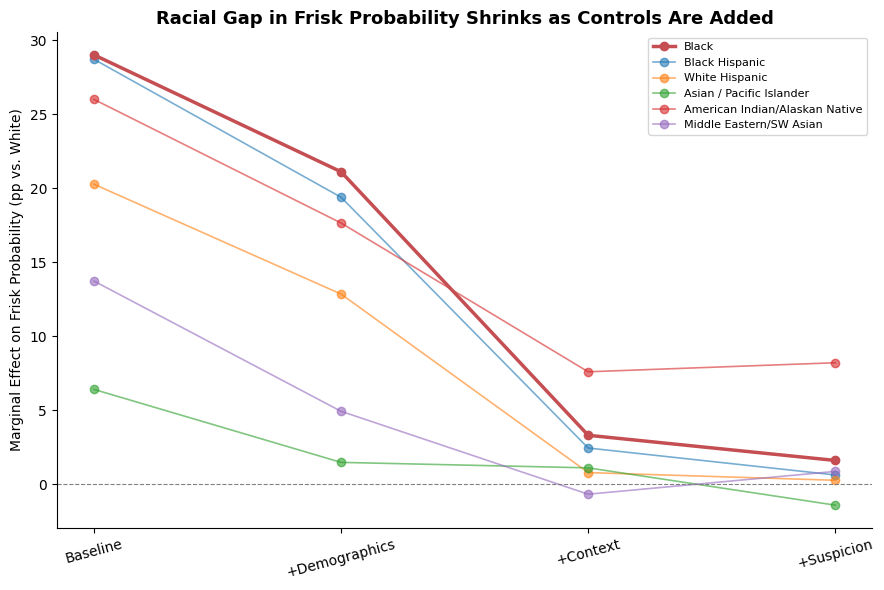

In [25]:
models = ['Baseline', '+Demographics', '+Context', '+Suspicion']

race_trajectories = {
    'Black': [29.0, 21.1, 3.3, 1.6],
    'Black Hispanic': [28.70, 19.38, 2.44, 0.62], 
    'White Hispanic': [20.26, 12.84, 0.78, 0.26],
    'Asian / Pacific Islander': [6.4, 1.47, 1.1, -1.42],
    'American Indian/Alaskan Native': [25.99, 17.64, 7.59, 8.2],
    'Middle Eastern/SW Asian': [13.72, 4.92, -0.68, 0.86],
}

plt.figure(figsize=(9, 6))
for race, vals in race_trajectories.items():
    if race == 'Black':
        plt.plot(models, vals, marker='o', linewidth=2.5,
                 color='#C44E52', label=race, zorder=5)  # emphasized
    else:
        plt.plot(models, vals, marker='o', linewidth=1.2,
                 alpha=0.6, label=race)

plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.ylabel('Marginal Effect on Frisk Probability (pp vs. White)')
plt.title('Racial Gap in Frisk Probability Shrinks as Controls Are Added',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=8, loc='upper right')
plt.xticks(rotation=15)
sns.despine()
plt.tight_layout()
plt.savefig('racial_gaps_frisks')
plt.show()

#### Question from this Data: What really caused the gaps to shrink?

Based on our data from adding each constant, we can see the gap shrink after each variable was added. Adding sex and race wasn't that substantial, but adding borough location, crime, and then suspicions really brought the gap down. Within the population of stopped suspects, after controlling for stop circumstances, the racial gaps in frisk probabilities are relatively small. This does not rule out bias upstream (in stop decisions) or bias embedded in the controls themselves.

In [26]:
results_table = summary_col(
    [model_baseline, model_demo, model_context, model_full],
    model_names=['Baseline', '+Demographics', '+Context', '+Suspicion'],
    stars=True,
    info_dict={'N': lambda x: f"{int(x.nobs):,}"}
)
print(results_table)


                                                                                             Baseline  +Demographics  +Context  +Suspicion
------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                   -0.9467*** 1.4529***     1.1924     0.6488    
                                                                                            (0.0542)   (0.1979)      (1.4599)   (1.4479)  
C(SUSPECT_RACE_DESCRIPTION, Treatment(reference="WHITE"))[T.BLACK]                          1.2250***  0.9386***     0.2154***  0.1428    
                                                                                            (0.0565)   (0.0592)      (0.0710)   (0.0874)  
C(SUSPECT_RACE_DESCRIPTION, Treatment(reference="WHITE"))[T.WHITE HISPANIC]                 0.8343***  0.5700***     0.0505     0.0237    
                          

#### Observations

1. As more controls are added, the Black coefficient shrinks substantially (from 1.225 to 0.143 in log-odds), and the standard error grows. By the full model, the residual gap is small and no longer statistically significant. The American Indian/Alaska Native coefficient remains significant, though it should be interpreted cautiously given the small sample size (n=81).
2. Female suspects remain a negative probability of being frisked, even adding background and suspicion keeps them at a negative probability and statisitcally significant.
3. Age has a negative correlation. Each additional year of age is associated with about a 0.1 percentage point reduction in frisk probability, so younger suspects are noticeably more likely to be frisked.
4. Borough coefficients have very large standard errors (around 1.4), making them statistically indistinguishable from the reference borough. This likely reflects collinearity between borough and other controls (suspected crime types, suspicion flags), which absorb much of the geographic variation.
5. CPW Suspected Crime remains highly significant and positive correlated (2.2031 to 2.3282)
6. Criminal Mischief becomes positive as you add the suspect values, moving from -.59 to +.39 when adding suspicion values. 
7. Being menacing has a high probability of being frisked
8. Borough coefficients have very large standard errors (around 1.4), making them statistically indistinguishable from the reference borough. This likely reflects collinearity between borough and other controls (suspected crime types, suspicion flags), which absorb much of the geographic variation.
9. Background circumstances (having committed violent crimes or known to carry a weapon) remain highly correlated and statistically significant. Violent crime flag: 4.68 (translates to +51 percentage points in marginal effects). Known to carry weapon flag: 3.39 (translates to +37 percentage points)

Issue: the analysis and the data cannot speak for who is actually being stopped in the first place

#### New Direction: Can we further analyze what the suspects with violent crime backgrounds and known to carry weapons are like? Let's explore if these variables are racially patterned.

In [27]:
flags = ['SUSPECTS_ACTIONS_CONCEALED_POSSESSION_WEAPON_FLAG_NUM',
        'SUSPECTS_ACTIONS_CASING_FLAG_NUM',
        'SUSPECTS_ACTIONS_DRUG_TRANSACTIONS_FLAG_NUM',
        'BACKROUND_CIRCUMSTANCES_VIOLENT_CRIME_FLAG_NUM',
        'BACKROUND_CIRCUMSTANCES_SUSPECT_KNOWN_TO_CARRY_WEAPON_FLAG_NUM']

flag_rates_by_race = df_reg.groupby('SUSPECT_RACE_DESCRIPTION')[flags].mean()
print(flag_rates_by_race)

                                SUSPECTS_ACTIONS_CONCEALED_POSSESSION_WEAPON_FLAG_NUM  \
SUSPECT_RACE_DESCRIPTION                                                                
WHITE                                                                    0.151891       
BLACK                                                                    0.456073       
WHITE HISPANIC                                                           0.337030       
BLACK HISPANIC                                                           0.417082       
ASIAN / PACIFIC ISLANDER                                                 0.130508       
AMERICAN INDIAN/ALASKAN NATIVE                                           0.358025       
MIDDLE EASTERN/SOUTHWEST ASIAN                                           0.271565       

                                SUSPECTS_ACTIONS_CASING_FLAG_NUM  \
SUSPECT_RACE_DESCRIPTION                                           
WHITE                                                   0.0608

Observations:
1. Concealed Possession of a Weapon: top 3 goes black (45.6%), black hispanic (41.7%), American Indian (35.8%) as compared to whites which are 15.2%. Black suspects are flagged for concealed possession of a weapon 3 times more often than whites. This was a flag that strongly predicted frisks in the previous model. 
2. Casing flag, whites have the highest rate for this flag
3. Drug transactions flag is low overall but Asian/Pacific Islander is highest
4. Violent Crime is even for all except American Indian
5. Known to carry weapon is highest for Black Hispanic, Asian, Black, White Hispanic

In [28]:
# What share of stops are for each crime, by race?
crime_by_race = pd.crosstab(
    df_reg['SUSPECT_RACE_DESCRIPTION'],
    df_reg['SUSPECTED_CRIME_DESCRIPTION'],
    normalize='index'
)
print(crime_by_race[['CPW', 'MENACING', 'ROBBERY', 'BURGLARY']])

SUSPECTED_CRIME_DESCRIPTION          CPW  MENACING   ROBBERY  BURGLARY
SUSPECT_RACE_DESCRIPTION                                              
WHITE                           0.199764  0.030142  0.050236  0.141253
BLACK                           0.540194  0.022076  0.084572  0.042351
WHITE HISPANIC                  0.407871  0.025045  0.097853  0.077102
BLACK HISPANIC                  0.492149  0.022214  0.090387  0.056683
ASIAN / PACIFIC ISLANDER        0.242373  0.038983  0.059322  0.113559
AMERICAN INDIAN/ALASKAN NATIVE  0.419753  0.012346  0.049383  0.061728
MIDDLE EASTERN/SOUTHWEST ASIAN  0.354633  0.035144  0.054313  0.092652


Observations:

For CPW: 54% of stops for black suspects are for CPW, while 20% of stops for white suspects are for CPW. Black Hispanics: 49% and American Indian 42%. In the previous regression model, CPW had a large crime type coefficient.

Suspicion flag rates vary substantially across racial groups, particularly for weapon-related flags. Black suspects are flagged for concealed weapon possession in 45.6% of stops, compared with 15.2% for White suspects — a threefold difference. Similar patterns appear for the Black Hispanic (41.7%) and American Indian (35.8%) groups. Casing and drug transaction flags show smaller and less consistent racial patterns. Background circumstance flags (violent crime, known weapon carrier) show meaningful but smaller gaps, with Black and Hispanic groups flagged at roughly 1.5x the rate of White suspects.

Suspected crime distributions show similar patterns. Stops of Black suspects are concentrated in CPW (criminal possession of weapon) at 54.0%, compared with 19.9% for White suspects. Conversely, White suspects are more likely to be stopped for property crimes such as burglary (14.1% vs. 4.2%).

These patterns matter for interpreting our regression results. The two strongest predictors of frisk decisions in our model — CPW and the concealed weapon possession flag — are precisely the variables that show the largest racial gaps. When regression "controls for" these factors, it absorbs the variation through which racial differences in frisk rates would mechanically appear. The dramatic shrinkage of the racial coefficient in our regression staircase therefore does not establish the absence of bias; it relocates the question to whether the suspicion framing itself is racially patterned, which our data cannot directly answer.

#### Below: a readable description of how much more likely other suspects are to be flagged for certain suspicions

In [29]:
rates = df_reg.groupby('SUSPECT_RACE_DESCRIPTION')[flags].mean()
ratios = rates.div(rates.loc['WHITE'])  # Each row divided by White row
print(ratios.round(2))

                                SUSPECTS_ACTIONS_CONCEALED_POSSESSION_WEAPON_FLAG_NUM  \
SUSPECT_RACE_DESCRIPTION                                                                
WHITE                                                                        1.00       
BLACK                                                                        3.00       
WHITE HISPANIC                                                               2.22       
BLACK HISPANIC                                                               2.75       
ASIAN / PACIFIC ISLANDER                                                     0.86       
AMERICAN INDIAN/ALASKAN NATIVE                                               2.36       
MIDDLE EASTERN/SOUTHWEST ASIAN                                               1.79       

                                SUSPECTS_ACTIONS_CASING_FLAG_NUM  \
SUSPECT_RACE_DESCRIPTION                                           
WHITE                                                       1.

## Part 3: Hit Rates

#### Among frisked suspects, we must calculate the rate at which weapons (or contraband) were actually found, broken down by race.

The interpretive logic — first formalized by Knowles, Persico, and Todd (2001) — goes like this: if officers are applying a race-neutral threshold of suspicion, the weapon-find rate should be approximately equal across racial groups at the margin. If officers frisk a particular group on weaker evidence (a lower threshold of suspicion), they'll generate more "false alarms" for that group, and the weapon-find rate for that group will be lower. Conversely, if they frisk a group on stronger evidence, the find rate will be higher.

1. Equal hit rates across races -> consistent with race-neutral thresholds
2. Lower hit rate for Black suspects -> consistent with lower threshold (frisking on weaker evidence)
3. Higher hit rate for Black suspects -> consistent with higher threshold (frisking on stronger evidence)

### How to define a hit?

#### Given these columns: 'WEAPON_FOUND_FLAG', 'FIREARM_FLAG', 'KNIFE_CUTTER_FLAG', 'OTHER_WEAPON_FLAG', 'OTHER_CONTRABAND_FLAG', I select 'WEAPON_FOUND_FLAG' as that defines a frisk

Since the below columns are Y/N outputs I conver them to 0/1 (binary)

In [30]:
df_reg['WEAPON_FOUND_NUM'] = (df_reg['WEAPON_FOUND_FLAG'] == 'Y').astype(int)
df_reg['CONTRABAND_FOUND_NUM'] = (df_reg['OTHER_CONTRABAND_FLAG'] == 'Y').astype(int)
df_reg['ANY_HIT_NUM'] = ((df_reg['WEAPON_FOUND_FLAG'] == 'Y') | 
                         (df_reg['OTHER_CONTRABAND_FLAG'] == 'Y')).astype(int)

In [31]:
df_frisked = df_reg[df_reg['FRISKED_NUM'] == 1].copy()
print(f"Total frisks: {len(df_frisked)}")
print(f"Total weapons found: {df_frisked['WEAPON_FOUND_NUM'].sum()}")
print(f"Overall weapon hit rate: {df_frisked['WEAPON_FOUND_NUM'].mean():.3f}")

Total frisks: 13780
Total weapons found: 2221
Overall weapon hit rate: 0.161


In [32]:
hit_rates = df_frisked.groupby('SUSPECT_RACE_DESCRIPTION').agg(
    n_frisks=('WEAPON_FOUND_NUM', 'count'),
    weapon_hit_rate=('WEAPON_FOUND_NUM', 'mean'),
    contraband_hit_rate=('CONTRABAND_FOUND_NUM', 'mean'),
    any_hit_rate=('ANY_HIT_NUM', 'mean')
).round(4)

print(hit_rates)

                                n_frisks  weapon_hit_rate  \
SUSPECT_RACE_DESCRIPTION                                    
WHITE                                473           0.1966   
BLACK                               8843           0.1537   
WHITE HISPANIC                      2638           0.1797   
BLACK HISPANIC                      1458           0.1571   
ASIAN / PACIFIC ISLANDER             198           0.1919   
AMERICAN INDIAN/ALASKAN NATIVE        43           0.0698   
MIDDLE EASTERN/SOUTHWEST ASIAN       127           0.1969   

                                contraband_hit_rate  any_hit_rate  
SUSPECT_RACE_DESCRIPTION                                           
WHITE                                        0.0846        0.2600  
BLACK                                        0.0384        0.1786  
WHITE HISPANIC                               0.0508        0.2130  
BLACK HISPANIC                               0.0432        0.1886  
ASIAN / PACIFIC ISLANDER                  

#### Observations:
1. Looking at n_frisks, Black suspects lead with 8843 frisks, White Hispanic suspects are in second with 2638 frisks, and Black Hispanic in 3rd with 1458 frisks. White suspects are next with 473 frisks.
2. The weapon hit rate is actually higher for White suspects (19.6%), Black suspects have a 15.37% hit rate, White Hispanics with 17.97%, but Asian/Pacific Islanders have a 19.19% hit rate with 198 n_frisks, and Middle Eastern/Southwest Asians have a 19.69% hit rate with 127 frisks
3. For contraband, White suspects have a 8.46% hit rate, Blacks with a 3.84% hit rate, White Hispanics aith a 5% hit rate and Black Hispanics aith a 4.32 hit rate. Asian/Pacific Islanders have a 6% hit rate and Middle Eastern/Southwest Asians with a 7.87% hit rate
4. Overall, White suspects have the highest hit rate but one of the lowest n_frisks. Black suspects have the second lowest overall hit rate (17.86%) and the most frisks

#### Adding Confidence Intervals

In [33]:
from scipy import stats

def proportion_ci(successes, n, confidence=0.95):
    """Wilson confidence interval for a proportion."""
    if n == 0:
        return (np.nan, np.nan)
    p = successes / n
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    denom = 1 + z**2/n
    center = (p + z**2/(2*n)) / denom
    margin = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return (center - margin, center + margin)

results = []
for race in df_frisked['SUSPECT_RACE_DESCRIPTION'].unique():
    sub = df_frisked[df_frisked['SUSPECT_RACE_DESCRIPTION'] == race]
    n = len(sub)
    hits = sub['WEAPON_FOUND_NUM'].sum()
    rate = hits / n if n > 0 else np.nan
    ci_low, ci_high = proportion_ci(hits, n)
    results.append({
        'race': race,
        'n_frisks': n,
        'weapons_found': hits,
        'hit_rate': rate,
        'ci_low': ci_low,
        'ci_high': ci_high
    })

hit_rate_df = pd.DataFrame(results).sort_values('n_frisks', ascending=False)
print(hit_rate_df)

                             race  n_frisks  weapons_found  hit_rate  \
0                           BLACK      8843           1359  0.153681   
1                  WHITE HISPANIC      2638            474  0.179682   
2                  BLACK HISPANIC      1458            229  0.157064   
5                           WHITE       473             93  0.196617   
4        ASIAN / PACIFIC ISLANDER       198             38  0.191919   
3  MIDDLE EASTERN/SOUTHWEST ASIAN       127             25  0.196850   
6  AMERICAN INDIAN/ALASKAN NATIVE        43              3  0.069767   

     ci_low   ci_high  
0  0.146315  0.161348  
1  0.165500  0.194795  
2  0.139292  0.176640  
5  0.163305  0.234818  
4  0.143138  0.252427  
3  0.137041  0.274460  
6  0.024012  0.186090  


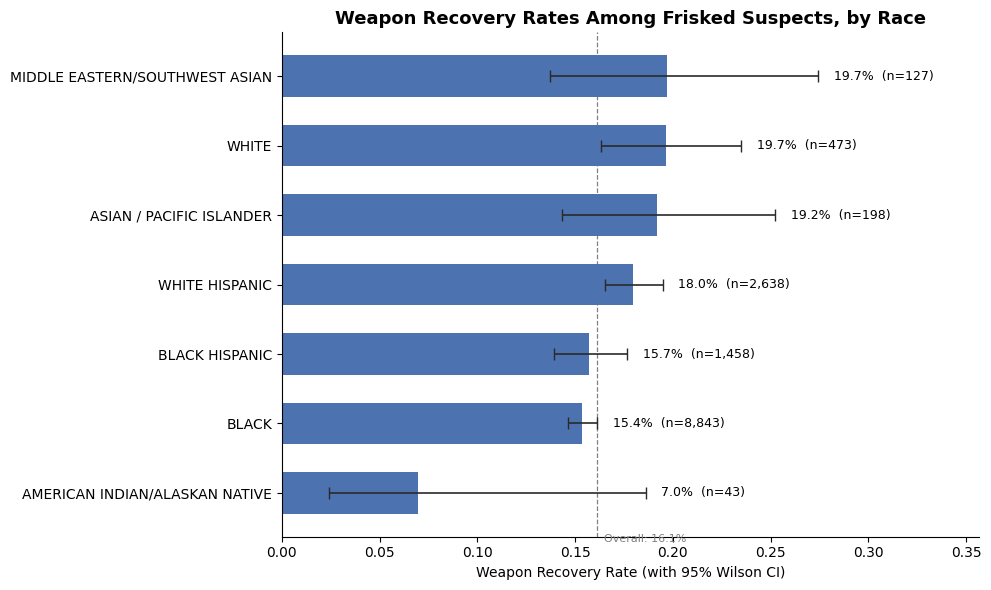

In [34]:
# Sort by hit rate so the chart has a visual logic
plot_df = hit_rate_df.sort_values('hit_rate', ascending=True).reset_index(drop=True)

# Error bars: distance from the point estimate to each CI bound
lower_err = plot_df['hit_rate'] - plot_df['ci_low']
upper_err = plot_df['ci_high'] - plot_df['hit_rate']

plt.figure(figsize=(10, 6))
ax = plt.gca()

# Horizontal bars
ax.barh(
    plot_df['race'],
    plot_df['hit_rate'],
    color='#4C72B0',
    height=0.6,
    zorder=2
)

# Error bars (Wilson CIs)
ax.errorbar(
    plot_df['hit_rate'],
    plot_df['race'],
    xerr=[lower_err, upper_err],
    fmt='none',
    ecolor='#2A2A2A',
    capsize=4,
    linewidth=1.2,
    zorder=3
)

# Annotate each bar with rate and sample size
for i, row in plot_df.iterrows():
    ax.text(
        row['ci_high'] + 0.008, i,
        f"{row['hit_rate']:.1%}  (n={int(row['n_frisks']):,})",
        va='center', fontsize=9
    )

# Overall recovery rate reference line
overall_rate = 0.161  # confirm against your Cell 58 output
ax.axvline(overall_rate, color='gray', linestyle='--', linewidth=0.9, zorder=1)
ax.text(overall_rate + 0.004, -0.7, f'Overall: {overall_rate:.1%}',
        fontsize=8, color='gray')

ax.set_xlabel('Weapon Recovery Rate (with 95% Wilson CI)')
ax.set_ylabel('')
ax.set_title('Weapon Recovery Rates Among Frisked Suspects, by Race',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, plot_df['ci_high'].max() * 1.30)  # room for labels
sns.despine()
plt.tight_layout()
plt.savefig('weapon_recovery_by_race')
plt.show()

#### Observations:
1. Confidence interval is smaller for Black suspects (14.6 - 16.1) compared to White suspects which is 16.3 - 23.48

#### Chi-Squared Test to see if the hit rates differ significantly across races

In [35]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    df_frisked['SUSPECT_RACE_DESCRIPTION'],
    df_frisked['WEAPON_FOUND_NUM']
)
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"Chi-square: {chi2:.2f}")
print(f"p-value: {p_value:.4f}")

Chi-square: 20.17
p-value: 0.0026


#### P-value is 0.0026 (less than 0.05), so hit rates differ significantly across racial groups

In [36]:
black_data = df_frisked[df_frisked['SUSPECT_RACE_DESCRIPTION'] == 'BLACK']
white_data = df_frisked[df_frisked['SUSPECT_RACE_DESCRIPTION'] == 'WHITE']

counts = [black_data['WEAPON_FOUND_NUM'].sum(), white_data['WEAPON_FOUND_NUM'].sum()]
nobs = [len(black_data), len(white_data)]

z_stat, p_val = proportions_ztest(counts, nobs)
print(f"Black hit rate: {counts[0]/nobs[0]:.4f}")
print(f"White hit rate: {counts[1]/nobs[1]:.4f}")
print(f"Difference: {(counts[0]/nobs[0]) - (counts[1]/nobs[1]):.4f}")
print(f"p-value: {p_val:.4f}")

Black hit rate: 0.1537
White hit rate: 0.1966
Difference: -0.0429
p-value: 0.0121


In [37]:
# Diagnose the convergence problem: which crimes have too few frisks or hits?
crime_counts = df_frisked.groupby('SUSPECTED_CRIME_DESCRIPTION').agg(
    n_frisks=('WEAPON_FOUND_NUM', 'count'),
    weapons_found=('WEAPON_FOUND_NUM', 'sum')
).sort_values('n_frisks', ascending=False)
print(crime_counts)

                                             n_frisks  weapons_found
SUSPECTED_CRIME_DESCRIPTION                                         
CPW                                             10318           1711
ROBBERY                                           933            163
ASSAULT                                           613             88
BURGLARY                                          348             38
MENACING                                          343             82
OTHER                                             274             25
PETIT LARCENY                                     227             14
GRAND LARCENY AUTO                                155             17
RECKLESS ENDANGERMENT                             115             19
GRAND LARCENY                                     108              9
CRIMINAL MISCHIEF                                  67             14
CRIMINAL POSSESSION OF CONTROLLED SUBSTANCE        55              6
CRIMINAL TRESPASS                 

In [38]:
# Keep only crime categories with enough data to estimate stably
common_crimes = crime_counts[
    (crime_counts['n_frisks'] >= 50) & 
    (crime_counts['weapons_found'] >= 5)
].index.tolist()

print(f"Keeping {len(common_crimes)} crime categories out of {len(crime_counts)}")
print(f"Dropping: {set(crime_counts.index) - set(common_crimes)}")

df_frisked_clean = df_frisked[df_frisked['SUSPECTED_CRIME_DESCRIPTION'].isin(common_crimes)].copy()
print(f"Rows before filter: {len(df_frisked)}")
print(f"Rows after filter: {len(df_frisked_clean)}")

Keeping 13 crime categories out of 27
Dropping: {'THEFT OF SERVICES', 'FORCIBLE TOUCHING', 'MURDER', 'TERRORISM', 'RAPE', 'CPSP', 'MAKING GRAFFITI', 'CRIMINAL POSSESSION OF MARIHUANA', 'CRIMINAL POSSESSION OF FORGED INSTRUMENT', 'CRIMINAL SALE OF MARIHUANA', 'CRIMINAL SALE OF CONTROLLED SUBSTANCE', 'AUTO STRIPPING', 'UNAUTHORIZED USE OF A VEHICLE', 'PROSTITUTION'}
Rows before filter: 13780
Rows after filter: 13610


In [39]:
hit_model_clean = smf.logit(
    '''WEAPON_FOUND_NUM ~ C(SUSPECT_RACE_DESCRIPTION, Treatment(reference="WHITE"))
       + C(SUSPECT_SEX)
       + SUSPECT_REPORTED_AGE
       + C(STOP_LOCATION_BORO_NAME)
       + C(SUSPECTED_CRIME_DESCRIPTION)
       + SUSPECTS_ACTIONS_CONCEALED_POSSESSION_WEAPON_FLAG_NUM
       + BACKROUND_CIRCUMSTANCES_VIOLENT_CRIME_FLAG_NUM
       + BACKROUND_CIRCUMSTANCES_SUSPECT_KNOWN_TO_CARRY_WEAPON_FLAG_NUM''',
    data=df_frisked_clean
).fit()

print(hit_model_clean.summary())

mfx_hit_clean = hit_model_clean.get_margeff(at='overall')
print(mfx_hit_clean.summary())

Optimization terminated successfully.
         Current function value: 0.434893
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:       WEAPON_FOUND_NUM   No. Observations:                13610
Model:                          Logit   Df Residuals:                    13580
Method:                           MLE   Df Model:                           29
Date:                Sat, 16 May 2026   Pseudo R-squ.:                 0.01479
Time:                        16:01:59   Log-Likelihood:                -5918.9
converged:                       True   LL-Null:                       -6007.7
Covariance Type:            nonrobust   LLR p-value:                 2.717e-23
                                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------

#### Using marginal effects, we can examine these findings from the data:
1. Black suspects coefficient is -4.6, statistically significant (p-value = 0.006)
2. Black Hispanic coefficient -3.81, p-value = 0.044, statistically significant

Black suspects are 4.6 points less likely to recover a weapon than in frisks of White suspects. 